In [5]:
import pandas as pd
import numpy as np

%matplotlib inline
# matplotlib.use('TkAgg')  # or 'QtAgg', etc.

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'ieee'])
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

In [62]:
### Plotting checksum related data for final paper ###

# Load tab-delimited file
# df = pd.read_csv('moving_in_circles.txt', delimiter='\t', header=None)
df = pd.read_csv('../position_checksum_test_1.txt', delimiter='\t', header=None)
df.columns = ['timestamp_ms', 'x', 'y', 'z', 'valid']

# Extract as NumPy arrays
t = (1/1000) * df['timestamp_ms'].to_numpy()
x = df['x'].to_numpy()
y = df['y'].to_numpy()
z = df['z'].to_numpy()
valid = df['valid'].to_numpy()

# Take subset of data for plotting
subset_idx = slice(6000, 10000)  # Adjust slice as needed
t = t[subset_idx]
x = x[subset_idx]
y = y[subset_idx]
z = z[subset_idx]
valid = valid[subset_idx]

In [ ]:
# # Test plotting of position data
# plt.figure()
# plt.plot(t, x, linestyle='-', label='x')
# plt.plot(t,y, linestyle='-', label='y')
# plt.plot(t,z, linestyle='-', label='z')
# plt.xlabel('Time (s)')
# plt.ylabel('Position (m)')
# plt.title("Position data")
# plt.legend()
# plt.savefig("raw_without_checksum_1.pdf", bbox_inches='tight')
# plt.show()

# # Calculating frequency at which data is received
# est_freq = 1 / np.mean(np.diff(t))  # in Hz
# # Printing estimated frequency
# print(f"Estimated Frequency: {est_freq} Hz")

# # Plot validity of data
# plt.figure()
# plt.plot(t, valid, label='validity')
# plt.title("Validity of data over time")
# plt.xlabel("Time (s)")
# plt.ylabel("Validity")
# plt.legend(loc=(1.01, 0.8))
# plt.savefig("checksum_validity_1.pdf", bbox_inches='tight')
# plt.show()

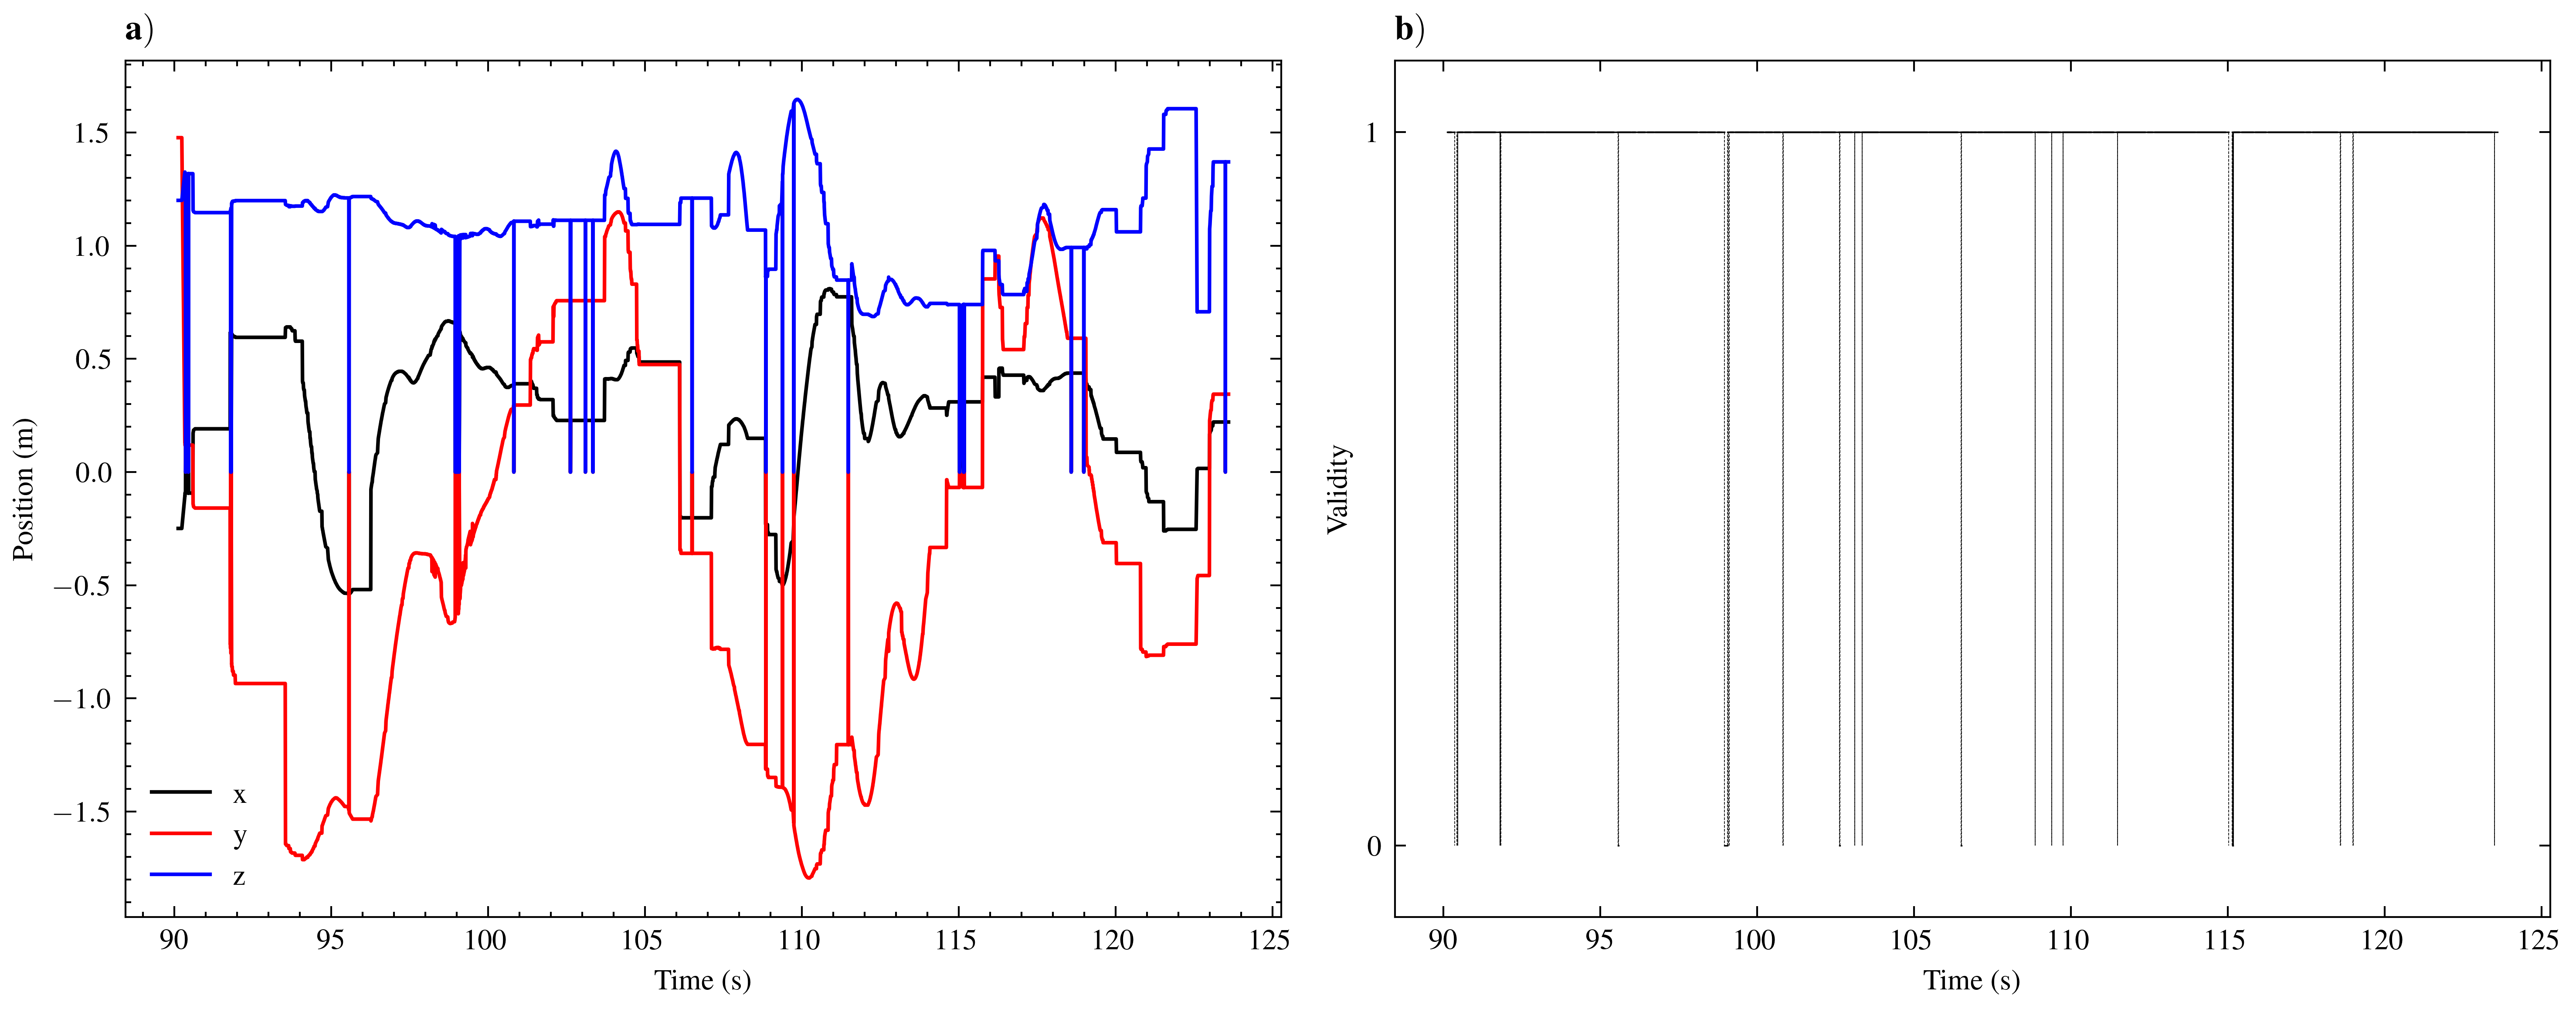

In [66]:
# Plot raw and validity in a subplot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(t, x, linestyle='-', label='x')
plt.plot(t, y, linestyle='-', label='y')
plt.plot(t, z, linestyle='-', label='z')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title(r'$\bf{a)}$', loc='left')
plt.legend()
ax = plt.subplot(1,2,2)
# Plot horizontal lines
# ax.plot(t, valid, 'k-', label='validity', drawstyle='steps-post', linewidth=0.8)
# Add vertical dashed lines at transitions
for i in range(1, len(t)):
    if valid[i] != valid[i-1]:
        ax.plot([t[i], t[i]], [valid[i-1], valid[i]], 'k--', linewidth=0.2)
    else:
        ax.plot([t[i-1], t[i]], [valid[i], valid[i]], 'k-', linewidth=0.4)
ax.set_title(r'$\bf{b)}$', loc='left')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Validity")
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 1])
ax.minorticks_off()   # disable minor ticks so no tick lines appear between 0 and 1
# plt.legend(loc=(1.01, 0.8))
plt.tight_layout()
plt.savefig("raw_and_validity_1.pdf", bbox_inches='tight')
plt.show()

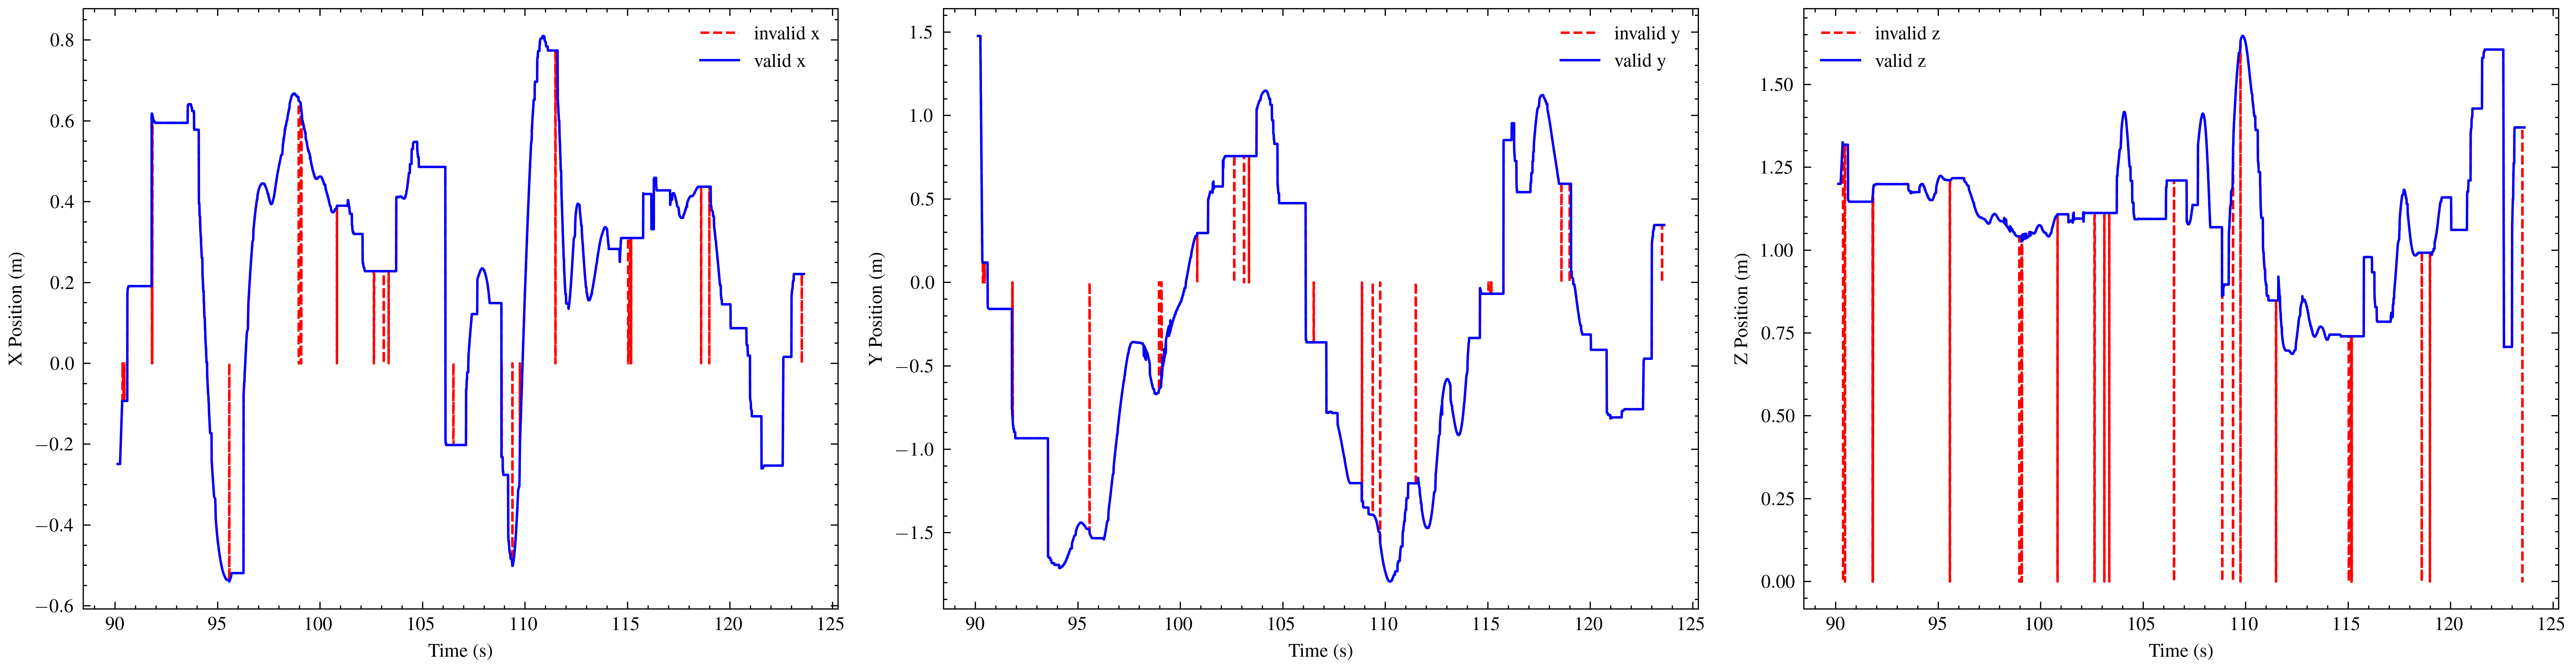

In [67]:
# Create new arrays for valid data only
t_valid = t[valid == 1]
x_valid = x[valid == 1]
y_valid = y[valid == 1]
z_valid = z[valid == 1]

# Plot invalid and valid data together for each axis, in a 1x3 subplot
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.plot(t, x, 'r--', label='invalid x')
plt.plot(t_valid, x_valid, 'b-', label='valid x')
plt.xlabel('Time (s)')
plt.ylabel('X Position (m)')
ax.set_title(r'$\bf{a)}$', loc='left')
plt.legend()

plt.subplot(1,3,2)
plt.plot(t, y, 'r--', label='invalid y')
plt.plot(t_valid, y_valid, 'b-', label='valid y')
plt.xlabel('Time (s)')
plt.ylabel('Y Position (m)')
ax.set_title(r'$\bf{b)}$', loc='left')
plt.legend()

plt.subplot(1,3,3)
plt.plot(t, z, 'r--', label='invalid z')
plt.plot(t_valid, z_valid, 'b-', label='valid z')
plt.xlabel('Time (s)')
plt.ylabel('Z Position (m)')
ax.set_title(r'$\bf{c)}$', loc='left')
plt.legend()

plt.tight_layout()
plt.savefig("valid_vs_invalid_1.pdf", bbox_inches='tight')
plt.show()